In [ ]:
import psycopg 
import os
from dotenv import load_dotenv
import mlflow
import pandas as pd
import matplotlib.pyplot as plt

from autofeat import AutoFeatClassifier
import pandas as pd
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)



DB_DESTINATION_HOST = os.getenv("DB_DESTINATION_HOST")
DB_DESTINATION_PORT = os.getenv("DB_DESTINATION_PORT")
DB_DESTINATION_NAME = os.getenv("DB_DESTINATION_NAME")
DB_DESTINATION_USER = os.getenv("DB_DESTINATION_USER")
DB_DESTINATION_PASSWORD = os.getenv("DB_DESTINATION_PASSWORD")

load_dotenv()
connection = {
    "sslmode": "require",
    "target_session_attrs": "read-write"
}

postgres_credentials = {
    "host": DB_DESTINATION_HOST,
    "port": DB_DESTINATION_PORT,
    "dbname": DB_DESTINATION_NAME,
    "user": DB_DESTINATION_USER,
    "password": DB_DESTINATION_PASSWORD,
}

assert all(
    var_value != "" and var_value is not None
    for var_value in postgres_credentials.values()
)

connection.update(postgres_credentials)

TABLE_NAME = "users_churn"

with psycopg.connect(**connection) as conn:
    with conn.cursor() as cur:
        cur.execute(f"SELECT * FROM {TABLE_NAME}")

        data = cur.fetchall()
        columns = [col[0] for col in cur.description]

df = pd.DataFrame(data, columns=columns)

df.head()

,id,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,internet_service,...,device_protection,tech_support,streaming_tv,streaming_movies,gender,senior_citizen,partner,dependents,multiple_lines,target
0,5768,8498-XXGWA,2014-09-01,NaT,Month-to-month,Yes,Mailed check,55.15,3673.15,DSL,...,Yes,No,No,No,Female,0,Yes,No,No,0
1,1,7590-VHVEG,2020-01-01,NaT,Month-to-month,Yes,Electronic check,29.85,29.85,DSL,...,No,No,No,No,Female,0,Yes,No,None,0
2,5,9237-HQITU,2019-09-01,2019-11-01,Month-to-month,Yes,Electronic check,70.70,151.65,Fiber optic,...,No,No,No,No,Female,0,No,No,No,1
3,6,9305-CDSKC,2019-03-01,2019-11-01,Month-to-month,Yes,Electronic check,99.65,820.50,Fiber optic,...,Yes,No,Yes,Yes,Female,0,No,No,Yes,1
4,7,1452-KIOVK,2018-04-01,NaT,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,Fiber optic,...,No,No,Yes,No,Male,0,No,Yes,Yes,0


In [44]:
with open("columns.txt", "w", encoding="utf-8") as fio:
    fio.write(",".join(df.columns))

In [45]:
counts_columns = [
    "type", "paperless_billing", "internet_service", "online_security", "online_backup", "device_protection",
    "tech_support", "streaming_tv", "streaming_movies", "gender", "senior_citizen", "partner", "dependents",
    "multiple_lines", "target"
]

stats = {}

for col in counts_columns:
    # 1. Считаем уникальные значения и преобразуем в словарь
    column_stat = df[col].value_counts().to_dict()
    column_stat = {f"{col}_{key}": value for key, value in column_stat.items()}

    # 2. Обновляем словарь stats полученными значениями
    stats.update(column_stat)


# 3. Расчет агрегированных метрик для числовых и текстовых колонок
stats["data_length"] = df.shape[0]
stats["monthly_charges_min"] = df["monthly_charges"].min()
stats["monthly_charges_max"] = df["monthly_charges"].max()          # Максимальное значение
stats["monthly_charges_mean"] = df["monthly_charges"].mean()        # Среднее значение
stats["monthly_charges_median"] = df["monthly_charges"].median()    # Медианное значение

stats["total_charges_min"] = df["total_charges"].min()              # Минимальное значение
stats["total_charges_max"] = df["total_charges"].max()              # Максимальное значение
stats["total_charges_mean"] = df["total_charges"].mean()            # Среднее значение
stats["total_charges_median"] = df["total_charges"].median()        # Медианное значение

stats["unique_customers_number"] = df["customer_id"].nunique()      # Кол-во уникальных ID
stats["end_date_nan"] = df["end_date"].isnull().sum()              # Кол-во пустых строк (NaN)


In [46]:
df.to_csv("users_churn.csv", index=False) 

In [47]:
full_data_set = df.copy()

In [48]:
# ============================================================
# RUN 1. MLflow connection + FINAL experiment + ONE main run
# ============================================================

import mlflow
import os


# ------------------------------------------------------------
# MLflow Tracking Server
# ------------------------------------------------------------

MLFLOW_TRACKING_URI = "http://127.0.0.1:5000"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

print("Tracking URI:", mlflow.get_tracking_uri())


# ------------------------------------------------------------
# Experiment / run settings
# ------------------------------------------------------------

EXPERIMENT_NAME = "churn__final_with_autofeat_v2"
RUN_NAME = "churn__final_run"


# ------------------------------------------------------------
# Закрываем случайно оставшийся run от предыдущего запуска
# ------------------------------------------------------------

if mlflow.active_run() is not None:
    mlflow.end_run()


# ------------------------------------------------------------
# Создаём НОВЫЙ experiment
#
# ВАЖНО:
# artifact_location вручную НЕ задаём.
#
# Tracking Server должен быть запущен:
#
# --default-artifact-root s3://<bucket_name>
# ------------------------------------------------------------

experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

if experiment is None:

    experiment_id = mlflow.create_experiment(
        name=EXPERIMENT_NAME
    )

    print("Experiment created.")

else:

    experiment_id = experiment.experiment_id

    print("Experiment already exists.")


experiment = mlflow.get_experiment(experiment_id)

print()
print("Experiment:", experiment.name)
print("Experiment ID:", experiment.experiment_id)
print("Experiment artifact location:")
print(experiment.artifact_location)


# ------------------------------------------------------------
# Проверяем experiment artifact location
# ------------------------------------------------------------

expected_experiment_suffix = f"/{experiment_id}"

if not experiment.artifact_location.endswith(
    expected_experiment_suffix
):
    raise RuntimeError(
        "\nНеправильный artifact_location эксперимента.\n"
        f"Expected ending: /{experiment_id}\n"
        f"Actual: {experiment.artifact_location}\n\n"
        "Скорее всего эксперимент был создан до перезапуска "
        "MLflow Server с --default-artifact-root s3://<bucket>.\n"
        "Создай эксперимент с НОВЫМ именем."
    )


# ------------------------------------------------------------
# START ONE MAIN RUN
# ------------------------------------------------------------

run = mlflow.start_run(
    experiment_id=experiment_id,
    run_name=RUN_NAME
)

run_id = run.info.run_id
artifact_uri = run.info.artifact_uri


print()
print("Run ID:", run_id)

print()
print("Run artifact URI:")
print(artifact_uri)


# ------------------------------------------------------------
# Проверяем требуемую структуру
# ------------------------------------------------------------

expected_part = (
    f"/{experiment_id}/{run_id}/artifacts"
)

if not artifact_uri.startswith("s3://"):
    raise RuntimeError(
        f"Artifact URI is not S3: {artifact_uri}"
    )

if expected_part not in artifact_uri:
    raise RuntimeError(
        "\nArtifact URI does not have required structure.\n"
        f"Expected:\n"
        f"s3://<bucket>/{experiment_id}/{run_id}/artifacts\n\n"
        f"Actual:\n"
        f"{artifact_uri}"
    )


print()
print("✓ MLflow experiment is correct")
print("✓ Main run started")
print("✓ Artifact URI has required structure")
print()
print(
    f"All following artifacts will be stored inside run {run_id}"
)

Tracking URI: http://127.0.0.1:5000
Experiment already exists.

Experiment: churn__final_with_autofeat_v2
Experiment ID: 8
Experiment artifact location:
s3://s3-student-mle-20260729-1a551ccfe6-freetrack/8

Run ID: a0575ae9d86b40b3aaeca0724de843cc

Run artifact URI:
s3://s3-student-mle-20260729-1a551ccfe6-freetrack/8/a0575ae9d86b40b3aaeca0724de843cc/artifacts

✓ MLflow experiment is correct
✓ Main run started
✓ Artifact URI has required structure

All following artifacts will be stored inside run a0575ae9d86b40b3aaeca0724de843cc


In [49]:
os.environ["MLFLOW_S3_ENDPOINT_URL"] = (
    "https://storage.yandexcloud.net"
)

print("AWS_ACCESS_KEY_ID:",
      "SET" if os.getenv("AWS_ACCESS_KEY_ID") else "NOT SET")

print("AWS_SECRET_ACCESS_KEY:",
      "SET" if os.getenv("AWS_SECRET_ACCESS_KEY") else "NOT SET")

print("MLFLOW_S3_ENDPOINT_URL:",
      os.getenv("MLFLOW_S3_ENDPOINT_URL"))

AWS_ACCESS_KEY_ID: SET
AWS_SECRET_ACCESS_KEY: SET
MLFLOW_S3_ENDPOINT_URL: https://storage.yandexcloud.net


Пропуски ДО обработки:
id                      0
customer_id             0
begin_date              0
end_date             5174
type                    0
paperless_billing       0
payment_method          0
monthly_charges         0
total_charges          11
internet_service     1526
online_security      1526
online_backup        1526
device_protection    1526
tech_support         1526
streaming_tv         1526
streaming_movies     1526
gender                  0
senior_citizen          0
partner                 0
dependents              0
multiple_lines        682
target                  0
dtype: int64



Пропуски ПОСЛЕ обработки:
id                      0
customer_id             0
begin_date              0
end_date             5174
type                    0
paperless_billing       0
payment_method          0
monthly_charges         0
total_charges          11
internet_service        0
online_security         0
online_backup           0
device_protection       0
tech_support            0
streaming_tv            0
streaming_movies        0
gender                  0
senior_citizen          0
partner                 0
dependents              0
multiple_lines          0
target                  0
dtype: int64

Распределение target:
end_date_flag
0    5174
1    1869
Name: count, dtype: int64


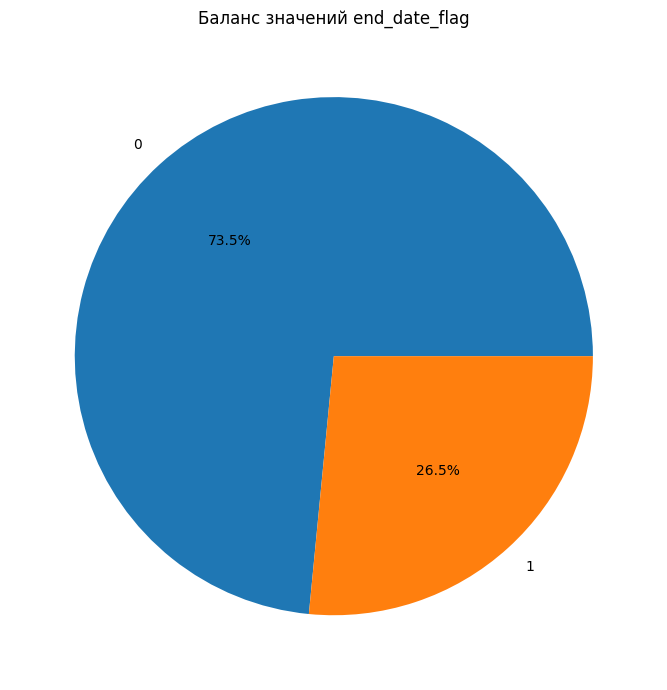

In [50]:
# ============================================================
# RUN 2. Missing values + target
# ============================================================

print("Пропуски ДО обработки:")
print(full_data_set.isna().sum())

missing_before = full_data_set.isna().sum()
missing_before = missing_before[missing_before > 0]

missing_before.to_csv("missing_before.csv")
mlflow.log_artifact("missing_before.csv", "eda")


# ------------------------------------------------------------
# Заполняем пропуски
# ------------------------------------------------------------

full_data_set["internet_service"] = (
    full_data_set["internet_service"]
    .fillna("No internet")
)

internet_dependent_cols = [
    "online_security",
    "online_backup",
    "device_protection",
    "tech_support",
    "streaming_tv",
    "streaming_movies"
]

for col in internet_dependent_cols:
    full_data_set[col] = (
        full_data_set[col]
        .fillna("No internet")
    )

full_data_set["multiple_lines"] = (
    full_data_set["multiple_lines"]
    .fillna("No phone service")
)


print("\nПропуски ПОСЛЕ обработки:")
print(full_data_set.isna().sum())

missing_after = full_data_set.isna().sum()
missing_after = missing_after[missing_after > 0]

missing_after.to_csv("missing_after.csv")
mlflow.log_artifact("missing_after.csv", "eda")


# ------------------------------------------------------------
# TARGET
# ------------------------------------------------------------

full_data_set["end_date_flag"] = (
    full_data_set["end_date"]
    .apply(lambda x: 0 if pd.isna(x) else 1)
)

print("\nРаспределение target:")
print(full_data_set["end_date_flag"].value_counts())

target_counts = full_data_set["end_date_flag"].value_counts()

mlflow.log_metric(
    "target_class_0",
    int(target_counts.get(0, 0))
)

mlflow.log_metric(
    "target_class_1",
    int(target_counts.get(1, 0))
)


# ------------------------------------------------------------
# Target visualization
# ------------------------------------------------------------

plt.figure(figsize=(7, 7))

full_data_set["end_date_flag"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Баланс значений end_date_flag")
plt.ylabel("")
plt.tight_layout()

plt.savefig(
    "target_balance.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close()

mlflow.log_artifact(
    "target_balance.png",
    "eda"
)

,monthly_charges,total_charges,contract_duration_days
count,7043.00,7032.00,7043.00
mean,64.76,2283.30,2761.60
std,30.09,2266.77,1503.56
min,18.25,18.80,30.00
25%,35.50,401.45,1767.00
50%,70.35,1397.48,3058.00
75%,89.85,3794.74,4031.00
max,118.75,8684.80,4608.00


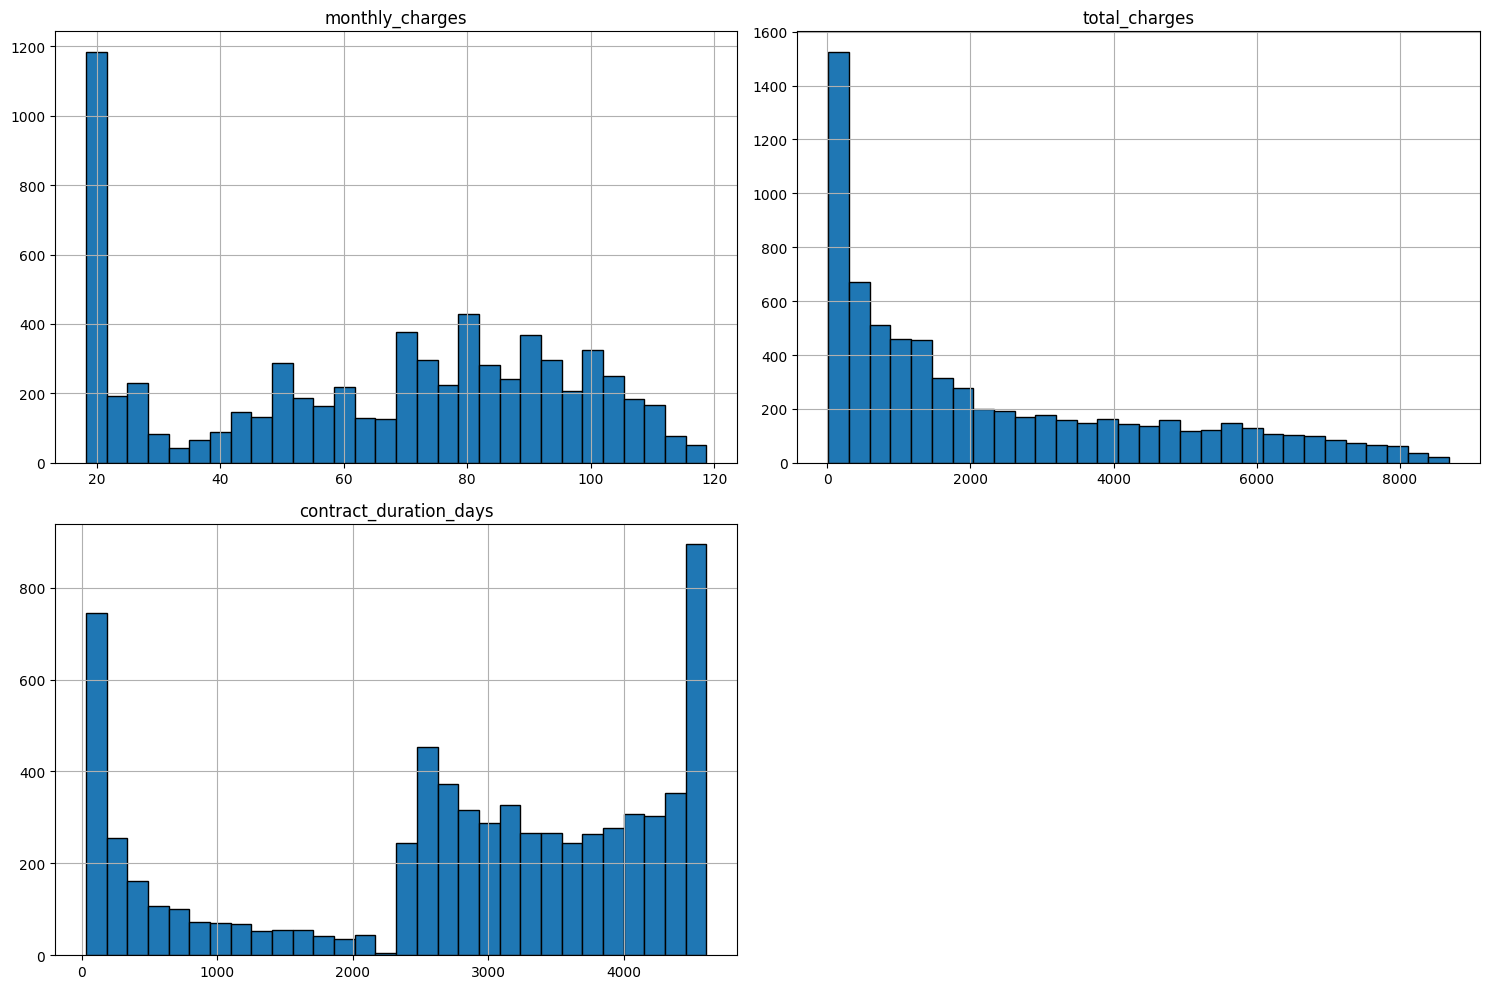

In [51]:
# ============================================================
# RUN 3. Dates + numerical features
# ============================================================

full_data_set["begin_date"] = pd.to_datetime(
    full_data_set["begin_date"],
    errors="coerce"
)

full_data_set["endDate"] = pd.to_datetime(
    full_data_set["end_date"],
    errors="coerce"
)

full_data_set["contract_duration_days"] = (
    full_data_set["endDate"].fillna(pd.Timestamp.today())
    - full_data_set["begin_date"]
).dt.days

full_data_set["contract_duration_months"] = (
    full_data_set["contract_duration_days"] / 30
).round()


# ------------------------------------------------------------
# Numerical features
# ------------------------------------------------------------

numeric_cols = [
    "monthly_charges",
    "total_charges",
    "contract_duration_days"
]

for col in numeric_cols:
    full_data_set[col] = pd.to_numeric(
        full_data_set[col],
        errors="coerce"
    )


# ------------------------------------------------------------
# Statistics
# ------------------------------------------------------------

numeric_stats = (
    full_data_set[numeric_cols]
    .describe()
    .round(2)
)

display(numeric_stats)

numeric_stats.to_csv(
    "numeric_statistics.csv"
)

mlflow.log_artifact(
    "numeric_statistics.csv",
    "eda"
)


# ------------------------------------------------------------
# Distributions
# ------------------------------------------------------------

full_data_set[numeric_cols].hist(
    figsize=(15, 10),
    bins=30,
    edgecolor="black"
)

plt.tight_layout()

plt.savefig(
    "numeric_distributions.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close()

mlflow.log_artifact(
    "numeric_distributions.png",
    "eda"
)

In [52]:
cols_to_drop = [
    'begin_date',
    'end_date',
    'endDate',
    'customer_id',
    'gender',
    'senior_citizen',
    'contract_duration_months',
    'target',
    'id',
    'contract_duration_days'
]
full_data_set = full_data_set.drop(
    columns=cols_to_drop,
    errors="ignore"
)

display(full_data_set.head())

,type,paperless_billing,payment_method,monthly_charges,total_charges,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,partner,dependents,multiple_lines,end_date_flag
0,Month-to-month,Yes,Mailed check,55.15,3673.15,DSL,Yes,No,Yes,No,No,No,Yes,No,No,0
1,Month-to-month,Yes,Electronic check,29.85,29.85,DSL,No,Yes,No,No,No,No,Yes,No,No phone service,0
2,Month-to-month,Yes,Electronic check,70.70,151.65,Fiber optic,No,No,No,No,No,No,No,No,No,1
3,Month-to-month,Yes,Electronic check,99.65,820.50,Fiber optic,No,No,Yes,No,Yes,Yes,No,No,Yes,1
4,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,Fiber optic,No,Yes,No,No,Yes,No,No,Yes,Yes,0


In [53]:
# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

# Target
y = full_data_set["end_date_flag"].copy()

# Признаки
X = full_data_set.drop(
    columns=["end_date_flag"],
    errors="ignore"
).copy()

# Разделение на train / test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Размер X:", X.shape)
print("Размер y:", y.shape)

print("\nРазмер X_train:", X_train.shape)
print("Размер X_test :", X_test.shape)

print("\nРазмер y_train:", y_train.shape)
print("Размер y_test :", y_test.shape)

print("\nРаспределение target:")
print("Train:")
print(y_train.value_counts(normalize=True))

print("\nTest:")
print(y_test.value_counts(normalize=True))

Размер X: (7043, 15)
Размер y: (7043,)

Размер X_train: (5634, 15)
Размер X_test : (1409, 15)

Размер y_train: (5634,)
Размер y_test : (1409,)

Распределение target:
Train:
end_date_flag
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Test:
end_date_flag
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [54]:
# ============================================================
# Задание 1. Генерация новых признаков AutoFeat
# ============================================================

# Категориальные признаки
cat_features = [
    'type',
    'paperless_billing',
    'payment_method',
    'internet_service',
    'online_security',
    'online_backup',
    'device_protection',
    'tech_support',
    'streaming_tv',
    'streaming_movies',
    'partner',
    'dependents',
    'multiple_lines',
]

# Числовые признаки
num_features = [
    'monthly_charges',
    'total_charges'
]

# Все признаки для обучения
features = cat_features + num_features

# ============================================================
# Проверяем наличие признаков
# ============================================================

print("Признаки X_train:")
print(X_train.columns.tolist())

print("\nПризнаки X_test:")
print(X_test.columns.tolist())

# ============================================================
# Создаём копии
# ============================================================

X_train_af = X_train[features].copy()
X_test_af = X_test[features].copy()

# ============================================================
# Обработка пропусков
# ============================================================

# Категориальные признаки
for col in cat_features:
    X_train_af[col] = X_train_af[col].fillna("Unknown")
    X_test_af[col] = X_test_af[col].fillna("Unknown")

# Числовые признаки
for col in num_features:
    median_value = X_train_af[col].median()
    
    X_train_af[col] = X_train_af[col].fillna(median_value)
    X_test_af[col] = X_test_af[col].fillna(median_value)

# ============================================================
# Проверка NaN
# ============================================================

print("\nКоличество NaN:")
print("X_train:", X_train_af.isna().sum().sum())
print("X_test :", X_test_af.isna().sum().sum())

# ============================================================
# AutoFeat
# ============================================================

transformations = (
    '1/',
    'log',
    'abs',
    'sqrt'
)

afc = AutoFeatClassifier(
    categorical_cols=cat_features,
    transformations=transformations,
    feateng_steps=1,
    n_jobs=-1
)

# ============================================================
# Генерация признаков на TRAIN
# ============================================================

X_train_features = afc.fit_transform(
    X_train_af,
    y_train
)

# ============================================================
# Генерация признаков на TEST
# ============================================================

X_test_features = afc.transform(
    X_test_af
)

# ============================================================
# Результаты
# ============================================================

print("\nРазмер X_train до AutoFeat:", X_train_af.shape)
print("Размер X_train после AutoFeat:", X_train_features.shape)

print("\nРазмер X_test до AutoFeat:", X_test_af.shape)
print("Размер X_test после AutoFeat:", X_test_features.shape)

print("\nСгенерированные признаки:")
print(X_train_features.columns.tolist())

Признаки X_train:
['type', 'paperless_billing', 'payment_method', 'monthly_charges', 'total_charges', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'partner', 'dependents', 'multiple_lines']

Признаки X_test:
['type', 'paperless_billing', 'payment_method', 'monthly_charges', 'total_charges', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'partner', 'dependents', 'multiple_lines']

Количество NaN:
X_train: 0
X_test : 0

Размер X_train до AutoFeat: (5634, 15)
Размер X_train после AutoFeat: (5634, 41)

Размер X_test до AutoFeat: (1409, 15)
Размер X_test после AutoFeat: (1409, 41)

Сгенерированные признаки:
['monthly_charges', 'total_charges', 'cat_type_Month-to-month', 'cat_type_One year', 'cat_type_Two year', 'cat_paperless_billing_No', 'cat_paperless_billing_Yes', 'cat_payment_method_Bank transfer (automatic)', 'cat_payment_

In [55]:


# ============================================================
# Подготавливаем target
# ============================================================

# Если y_train / y_test являются DataFrame с одной колонкой,
# преобразуем их в Series
if hasattr(y_train, "ndim") and y_train.ndim > 1:
    y_train_gb = y_train.iloc[:, 0]
else:
    y_train_gb = y_train

if hasattr(y_test, "ndim") and y_test.ndim > 1:
    y_test_gb = y_test.iloc[:, 0]
else:
    y_test_gb = y_test


# ============================================================
# Создаём модель
# ============================================================

gb_model = GradientBoostingClassifier(
    random_state=11225
)


# ============================================================
# Обучение модели
# ============================================================

gb_model.fit(
    X_train_features,
    y_train_gb
)


# ============================================================
# Предсказания
# ============================================================

y_pred = gb_model.predict(X_test_features)

# Вероятность положительного класса
y_pred_proba = gb_model.predict_proba(X_test_features)[:, 1]


# ============================================================
# Метрики
# ============================================================

auc_roc = roc_auc_score(
    y_test_gb,
    y_pred_proba
)

accuracy = accuracy_score(
    y_test_gb,
    y_pred
)

precision = precision_score(
    y_test_gb,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test_gb,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test_gb,
    y_pred,
    zero_division=0
)


# ============================================================
# Вывод метрик
# ============================================================

print("\n" + "=" * 60)
print("GradientBoostingClassifier + AutoFeat")
print("=" * 60)

print(f"AUC-ROC  : {auc_roc:.4f}")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")


# ============================================================
# Classification Report
# ============================================================

print("\nClassification Report:")
print(
    classification_report(
        y_test_gb,
        y_pred,
        zero_division=0
    )
)


# ============================================================
# Матрица ошибок
# ============================================================

cm = confusion_matrix(
    y_test_gb,
    y_pred
)

print("\nМатрица ошибок:")
print(cm)

print("\nРасшифровка:")
print(f"TN = {cm[0, 0]}")
print(f"FP = {cm[0, 1]}")
print(f"FN = {cm[1, 0]}")
print(f"TP = {cm[1, 1]}")


GradientBoostingClassifier + AutoFeat
AUC-ROC  : 0.8449
Accuracy : 0.8020
Precision: 0.6578
Recall   : 0.5294
F1-score : 0.5867

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409


Матрица ошибок:
[[932 103]
 [176 198]]

Расшифровка:
TN = 932
FP = 103
FN = 176
TP = 198


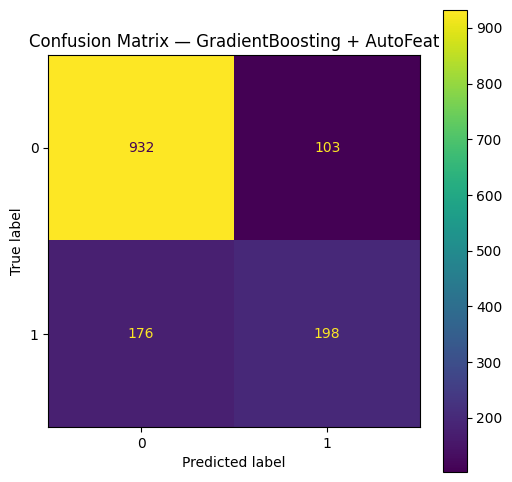

In [56]:
fig, ax = plt.subplots(figsize=(6, 6))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["0", "1"]
).plot(ax=ax)

ax.set_title("Confusion Matrix — GradientBoosting + AutoFeat")
plt.show()

In [57]:
# ============================================================
# LOG FINAL MODEL INTO CURRENT MLFLOW RUN
# ============================================================

assert mlflow.active_run() is not None, (
    "Нет активного MLflow run. "
    "Сначала выполни RUN 1."
)

# Метрики
mlflow.log_metrics({
    "roc_auc": float(auc_roc),
    "accuracy": float(accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "f1": float(f1),
})

# Сохраняем итоговую GradientBoosting модель
model_info = mlflow.sklearn.log_model(
    gb_model,
    artifact_path="model"
)

print("Run ID:", mlflow.active_run().info.run_id)
print("Run artifact URI:", mlflow.active_run().info.artifact_uri)
print("Model URI:", model_info.model_uri)

Run ID: a0575ae9d86b40b3aaeca0724de843cc
Run artifact URI: s3://s3-student-mle-20260729-1a551ccfe6-freetrack/8/a0575ae9d86b40b3aaeca0724de843cc/artifacts
Model URI: runs:/a0575ae9d86b40b3aaeca0724de843cc/model


In [59]:
# ============================================================
# Регистрация обученной модели
# ============================================================

MODEL_REGISTERED_NAME = "churn_with_autofeat_model"

# Получаем run_id текущего эксперимента
run_id = mlflow.active_run().info.run_id

# Сохраняем модель в этот run
mlflow.sklearn.log_model(
    sk_model=gb_model,
    artifact_path="model"
)

# Регистрируем модель
model_uri = f"runs:/{run_id}/model"

registered_model = mlflow.register_model(
    model_uri=model_uri,
    name=MODEL_REGISTERED_NAME
)

# ============================================================
# Ответ для задания
# ============================================================

model_version_id = int(registered_model.version)
model_registred_name = registered_model.name

print("model_version_id =", model_version_id)
print("model_registred_name =", model_registred_name)
print("run_id =", run_id)

Successfully registered model 'churn_with_autofeat_model'.
2026/09/14 18:22:57 INFO mlflow.tracking._model_registry.client: Waiting up to 300 seconds for model version to finish creation. Model name: churn_with_autofeat_model, version 1


model_version_id = 1
model_registred_name = churn_with_autofeat_model
run_id = a0575ae9d86b40b3aaeca0724de843cc


Created version '1' of model 'churn_with_autofeat_model'.


In [60]:
mlflow.end_run()

In [61]:
print("Tracking URI:", mlflow.get_tracking_uri())

exp = mlflow.get_experiment_by_name("churn__final_with_autofeat_v2")

print("Experiment ID:", exp.experiment_id)
print("Artifact Location:", exp.artifact_location)

Tracking URI: http://127.0.0.1:5000
Experiment ID: 8
Artifact Location: s3://s3-student-mle-20260729-1a551ccfe6-freetrack/8


In [62]:
from mlflow.tracking import MlflowClient

client = MlflowClient()

exp1 = client.get_experiment("1")

print("ID:", exp1.experiment_id)
print("Name:", exp1.name)
print("Artifact location:", exp1.artifact_location)

ID: 1
Name: churn_fio
Artifact location: s3://s3-student-mle-20260729-1a551ccfe6-freetrack/1


In [63]:
import mlflow
from mlflow.tracking import MlflowClient

mlflow.set_tracking_uri("http://127.0.0.1:5000")

client = MlflowClient()

experiment = client.get_experiment_by_name("churn__final_with_autofeat_v2")

print("Experiment ID:", experiment.experiment_id)
print("Experiment artifact location:", experiment.artifact_location)

runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["attributes.start_time DESC"]
)

print("\nКоличество runs:", len(runs))

for run in runs:
    print("\n" + "=" * 70)
    print("Run ID:", run.info.run_id)
    print("Run name:", run.data.tags.get("mlflow.runName"))
    print("Artifact URI:", run.info.artifact_uri)

    artifacts = client.list_artifacts(run.info.run_id)

    print("Artifacts:")
    if artifacts:
        for artifact in artifacts:
            print("  -", artifact.path)
    else:
        print("  НЕТ АРТЕФАКТОВ")

Experiment ID: 8
Experiment artifact location: s3://s3-student-mle-20260729-1a551ccfe6-freetrack/8

Количество runs: 6

Run ID: a0575ae9d86b40b3aaeca0724de843cc
Run name: churn__final_run
Artifact URI: s3://s3-student-mle-20260729-1a551ccfe6-freetrack/8/a0575ae9d86b40b3aaeca0724de843cc/artifacts
Artifacts:
  - eda
  - model

Run ID: 0ff5ea4f46b945429296953833995a92
Run name: churn__final_run
Artifact URI: s3://s3-student-mle-20260729-1a551ccfe6-freetrack/8/0ff5ea4f46b945429296953833995a92/artifacts
Artifacts:
  - eda
  - model

Run ID: 7c1b21af44764a659052dd24a7b1a738
Run name: churn__final_run
Artifact URI: s3://s3-student-mle-20260729-1a551ccfe6-freetrack/8/7c1b21af44764a659052dd24a7b1a738/artifacts
Artifacts:
  - eda

Run ID: 7ef32ca75c1141c1b30e27234a86d4b4
Run name: churn__final_run
Artifact URI: s3://s3-student-mle-20260729-1a551ccfe6-freetrack/8/7ef32ca75c1141c1b30e27234a86d4b4/artifacts
Artifacts:
  - eda

Run ID: 01aa138ef14e48ccb403107a7a2455d2
Run name: churn__final_run
Arti

In [64]:
from mlflow.tracking import MlflowClient

client = MlflowClient()

run_info = client.get_run(run_id)

print("Experiment ID:", run_info.info.experiment_id)
print("Run ID:", run_info.info.run_id)
print("Artifact URI:", run_info.info.artifact_uri)

Experiment ID: 8
Run ID: a0575ae9d86b40b3aaeca0724de843cc
Artifact URI: s3://s3-student-mle-20260729-1a551ccfe6-freetrack/8/a0575ae9d86b40b3aaeca0724de843cc/artifacts
